IMPORT LIBRARIES

In [ ]:
# === Importing Libraries ===

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Stacking Libraries
from sklearn.ensemble import StackingRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score


LOAD DATA

In [ ]:
data= pd.read_excel("./employee_burnout_analysis.xlsx")
data.head()

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3,7.0,6.9,0.52


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Employee ID           22750 non-null  object        
 1   Date of Joining       22750 non-null  datetime64[ns]
 2   Gender                22750 non-null  object        
 3   Company Type          22750 non-null  object        
 4   WFH Setup Available   22750 non-null  object        
 5   Designation           22750 non-null  int64         
 6   Resource Allocation   21369 non-null  float64       
 7   Mental Fatigue Score  20633 non-null  float64       
 8   Burn Rate             21626 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 1.6+ MB


DATA PREPROCESSING

In [ ]:
# Menghitung korelasi antara semua fitur numerik dengan variabel target 'Burn Rate'
# Tujuannya untuk mengetahui fitur mana yang paling berpengaruh terhadap burnout
data.corr(numeric_only=True)['Burn Rate'][:-1]

,Burn Rate
Designation,0.737556
Resource Allocation,0.856278
Mental Fatigue Score,0.944546


In [ ]:
data.isnull().sum().values.sum()

np.int64(4622)

In [ ]:
# Penanganan Missing Values
data = data.dropna()
data.shape

(18590, 9)

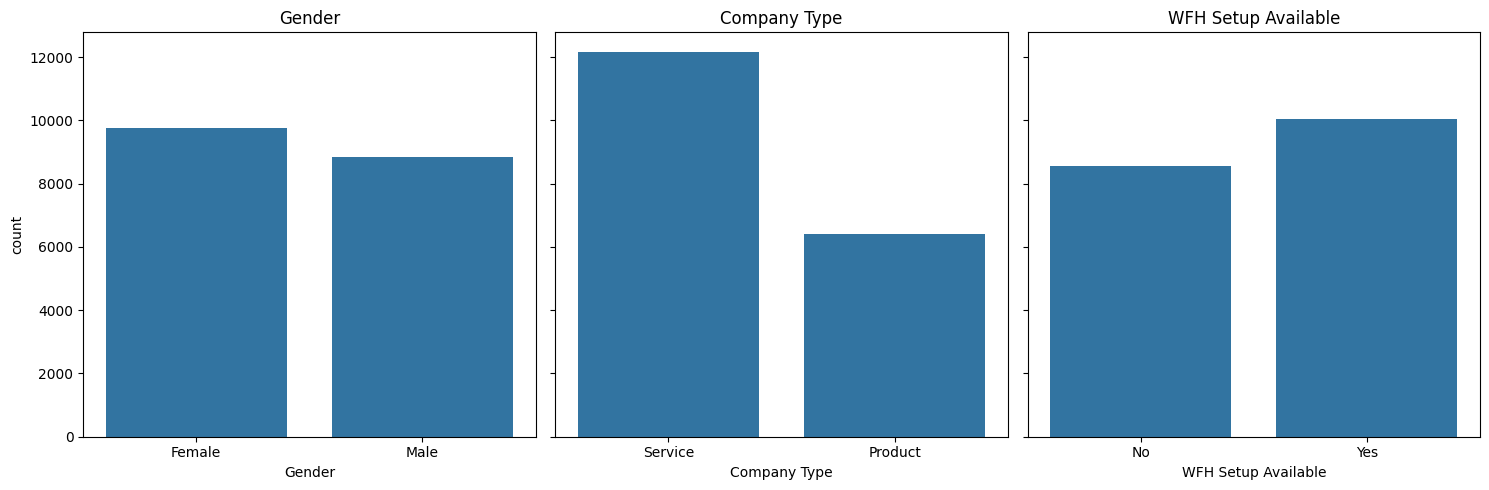

In [ ]:
# Cek Kolom Kategorikal
# Pilih kolom kategorikal, kecuali 'Employee ID'
cat_columns = data.select_dtypes(include='object').columns.drop('Employee ID', errors='ignore')

# Buat subplot sebanyak jumlah kolom kategorikal
fig, ax = plt.subplots(nrows=1, ncols=len(cat_columns), sharey=True, figsize=(5*len(cat_columns), 5))

# Jika cuma 1 kolom, ax bukan list, ubah menjadi list supaya looping aman
if len(cat_columns) == 1:
    ax = [ax]

# Plot countplot untuk tiap kolom
for i, c in enumerate(cat_columns):
    sns.countplot(x=c, data=data, ax=ax[i])
    ax[i].set_title(c)

plt.tight_layout()
plt.show()

In [ ]:
# Encoding
# Pastikan kolom kategorikal masih berupa string
# Gender
gender_dummies = pd.get_dummies(data['Gender'], prefix='Gender')
gender_dummies = gender_dummies.astype(int)  # Convert True/False menjadi 0/1
data = pd.concat([data.drop('Gender', axis=1), gender_dummies], axis=1)

# Company Type
company_dummies = pd.get_dummies(data['Company Type'], prefix='Company_Type')
company_dummies = company_dummies.astype(int)
data = pd.concat([data.drop('Company Type', axis=1), company_dummies], axis=1)

# WFH Setup Available
data['WFH Setup Available'] = data['WFH Setup Available'].map({'Yes': 1, 'No': 0}).astype(int)

# Cek 5 baris pertama
print(data.head())

                Employee ID Date of Joining  WFH Setup Available  Designation  \
0  fffe32003000360033003200      2008-09-30                    0            2   
1      fffe3700360033003500      2008-11-30                    1            1   
3  fffe32003400380032003900      2008-11-03                    1            1   
4  fffe31003900340031003600      2008-07-24                    0            3   
5      fffe3300350037003500      2008-11-26                    1            2   

   Resource Allocation  Mental Fatigue Score  Burn Rate  Gender_Female  \
0                  3.0                   3.8       0.16              1   
1                  2.0                   5.0       0.36              0   
3                  1.0                   2.6       0.20              0   
4                  7.0                   6.9       0.52              1   
5                  4.0                   3.6       0.29              0   

   Gender_Male  Company_Type_Product  Company_Type_Service  
0      

In [ ]:
# Feature Engineering
# Pastikan kolom Date of Joining bertipe datetime
data['Date of Joining'] = pd.to_datetime(data['Date of Joining'], format='%Y-%m-%d')

# Tentukan tanggal analisis
analysis_date = pd.to_datetime('2023-11-17')

# Buat kolom Tenure (dalam hari)
data['Tenure'] = (analysis_date - data['Date of Joining']).dt.days

# Cek 5 baris pertama
print(data[['Date of Joining', 'Tenure']].head())

  Date of Joining  Tenure
0      2008-09-30    5526
1      2008-11-30    5465
3      2008-11-03    5492
4      2008-07-24    5594
5      2008-11-26    5469


In [ ]:
# Scaling
# Pilih kolom yang ingin di-scale (misal semua kecuali Employee ID dan Date of Joining)
cols_to_scale = data.drop(columns=['Employee ID', 'Date of Joining', 'Burn Rate']).columns

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Lakukan scaling
data_scaled = data.copy()
data_scaled[cols_to_scale] = scaler.fit_transform(data_scaled[cols_to_scale])

# Cek 5 baris pertama
print(data_scaled.head())

                Employee ID Date of Joining  WFH Setup Available  Designation  \
0  fffe32003000360033003200      2008-09-30                  0.0          0.4   
1      fffe3700360033003500      2008-11-30                  1.0          0.2   
3  fffe32003400380032003900      2008-11-03                  1.0          0.2   
4  fffe31003900340031003600      2008-07-24                  0.0          0.6   
5      fffe3300350037003500      2008-11-26                  1.0          0.4   

   Resource Allocation  Mental Fatigue Score  Burn Rate  Gender_Female  \
0             0.222222                  0.38       0.16            1.0   
1             0.111111                  0.50       0.36            0.0   
3             0.000000                  0.26       0.20            0.0   
4             0.666667                  0.69       0.52            1.0   
5             0.333333                  0.36       0.29            0.0   

   Gender_Male  Company_Type_Product  Company_Type_Service    Tenure

BOOSTING

In [ ]:
# Model Training Boosting
# Split data
X = data_scaled.drop(columns=["Burn Rate", "Employee ID", "Date of Joining"])
y = data_scaled["Burn Rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define models
boosting_models = {
    "AdaBoost": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        objective="reg:squarederror"
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    )
}

# Training & Evaluation
boosting_results = []
for name, model in boosting_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    boosting_results.append([name, round(mse, 4), round(r2, 4)])

boosting_df = pd.DataFrame(boosting_results, columns=["Boosting model", "MSE", "R-squared"])
print("\n=== Performance of Boosting Models ===")
print(boosting_df.to_string(index=False))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 14872, number of used features: 9
[LightGBM] [Info] Start training from score 0.452021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

UJI XGBOOST KARENA HASIL ERROR PALING KECIL DAN R SQUARED PALING TINGGI

In [ ]:
# =====================
# 1. Siapkan fitur dan target
# =====================
X = data_scaled.drop(columns=['Employee ID', 'Date of Joining', 'Burn Rate'])
y = data_scaled['Burn Rate']

# =====================
# 2. Definisikan train-test-validation split
# =====================
splits = [
    (0.6, 0.2, 0.2),  # 60-20-20
    (0.7, 0.15, 0.15), # 70-15-15
    (0.8, 0.1, 0.1)   # 80-10-10
]

results = []

for train_size, val_size, test_size in splits:
    # Split train + temp (val+test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, train_size=train_size, random_state=42
    )
    # Hitung proporsi val & test terhadap temp
    val_ratio = val_size / (val_size + test_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=val_ratio, random_state=42
    )

    # =====================
    # 3. Train XGBoost
    # =====================
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)

    # =====================
    # 4. Evaluasi pada validation set
    # =====================
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    results.append({
        'Train-Test-Val split': f"{int(train_size*100)}-{int(val_size*100)}-{int(test_size*100)}",
        'Avg. MSE': mse,
        'Avg. R-squared': r2
    })

# =====================
# 5. Buat DataFrame untuk hasil
# =====================
results_df = pd.DataFrame(results)
print(results_df)

  Train-Test-Val split  Avg. MSE  Avg. R-squared
0             60-20-20  0.002783        0.926823
1             70-15-15  0.002825        0.927496
2             80-10-10  0.002828        0.927025


In [ ]:
# Hyperparameter Tuning (Grid Search)
# Definisikan model
xgb = XGBRegressor(random_state=42)

# Grid hyperparameters
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Grid search dengan 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best R2 score (CV):", grid_search.best_score_)

Best hyperparameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best R2 score (CV): 0.9282150148657223


=== Model Performance ===
Training Set -> MSE: 0.002677, R²: 0.9319
Validation Set -> MSE: 0.002775, R²: 0.9284


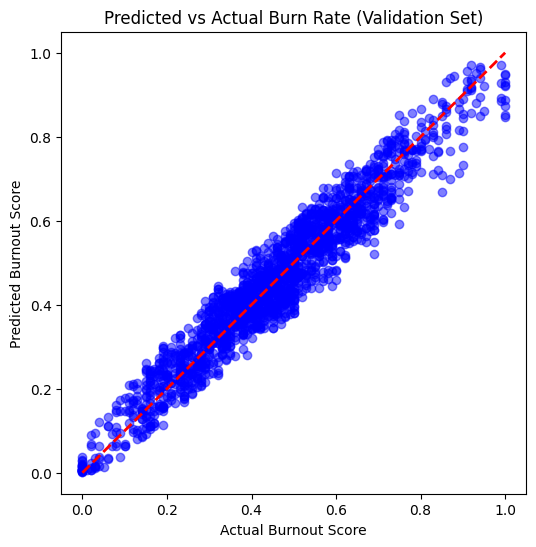

In [ ]:
# Ambil model terbaik dari Grid Search
final_model = grid_search.best_estimator_

# Prediksi pada training dan validation set
y_train_pred = final_model.predict(X_train)
y_val_pred = final_model.predict(X_val)

# Hitung MSE dan R-squared
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print("=== Model Performance ===")
print(f"Training Set -> MSE: {train_mse:.6f}, R²: {train_r2:.4f}")
print(f"Validation Set -> MSE: {val_mse:.6f}, R²: {val_r2:.4f}")

# Plot Predicted vs Actual
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.5, color='blue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)  # diagonal line
plt.xlabel('Actual Burnout Score')
plt.ylabel('Predicted Burnout Score')
plt.title('Predicted vs Actual Burn Rate (Validation Set)')
plt.show()

STACKING


=== Stacking Regressor Performance ===
Training Set -> MSE: 0.002269, R²: 0.9423
Validation Set -> MSE: 0.002803, R²: 0.9277


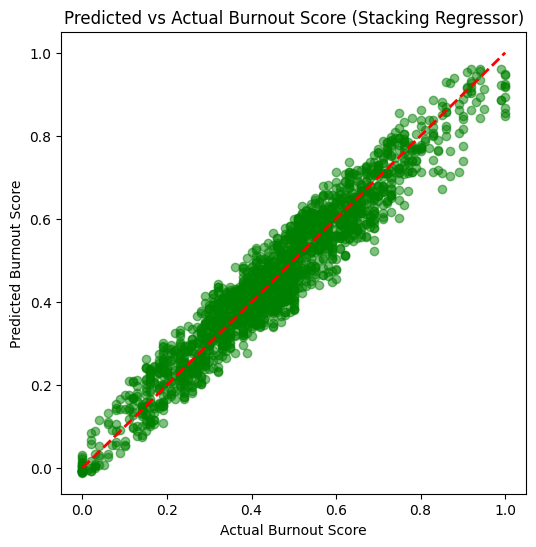

In [ ]:
# =====================================================
# STACKING REGRESSOR
# =====================================================

# Base learners
base_learners = [
    ("lr", LinearRegression()),
    ("ridge", Ridge(alpha=1.0)),
    ("svr", SVR(kernel='rbf', C=1.0, gamma='scale')),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("xgb", XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5,
                         random_state=42, objective="reg:squarederror"))
]

# Meta-model (stacking final estimator)
meta_model = Ridge(alpha=1.0)

# Definisikan stacking model
stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train stacking model
stacking_model.fit(X_train, y_train)

# Prediction
y_train_pred_stack = stacking_model.predict(X_train)
y_val_pred_stack = stacking_model.predict(X_val)

# Evaluation
stack_train_mse = mean_squared_error(y_train, y_train_pred_stack)
stack_train_r2 = r2_score(y_train, y_train_pred_stack)

stack_val_mse = mean_squared_error(y_val, y_val_pred_stack)
stack_val_r2 = r2_score(y_val, y_val_pred_stack)

print("\n=== Stacking Regressor Performance ===")
print(f"Training Set -> MSE: {stack_train_mse:.6f}, R²: {stack_train_r2:.4f}")
print(f"Validation Set -> MSE: {stack_val_mse:.6f}, R²: {stack_val_r2:.4f}")

# Plot Predicted vs Actual (Stacking)
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred_stack, alpha=0.5, color='green')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.xlabel('Actual Burnout Score')
plt.ylabel('Predicted Burnout Score')
plt.title('Predicted vs Actual Burnout Score (Stacking Regressor)')
plt.show()


=== Feature Importance (AdaBoost) ===
                Feature  Importance
3  Mental Fatigue Score    0.982433
2   Resource Allocation    0.016303
0   WFH Setup Available    0.000679
1           Designation    0.000572
8                Tenure    0.000013
4         Gender_Female    0.000000
5           Gender_Male    0.000000
6  Company_Type_Product    0.000000
7  Company_Type_Service    0.000000


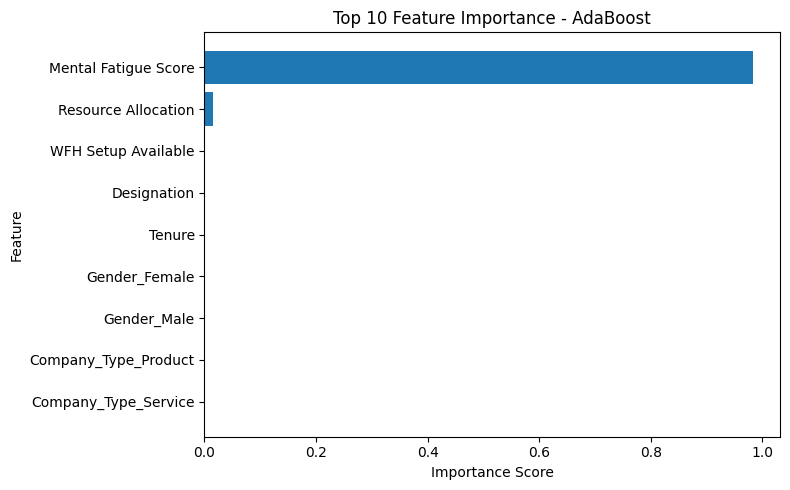


=== Feature Importance (GradientBoosting) ===
                Feature  Importance
3  Mental Fatigue Score    0.953509
2   Resource Allocation    0.039536
1           Designation    0.002695
0   WFH Setup Available    0.001888
8                Tenure    0.001786
4         Gender_Female    0.000215
5           Gender_Male    0.000194
6  Company_Type_Product    0.000117
7  Company_Type_Service    0.000061


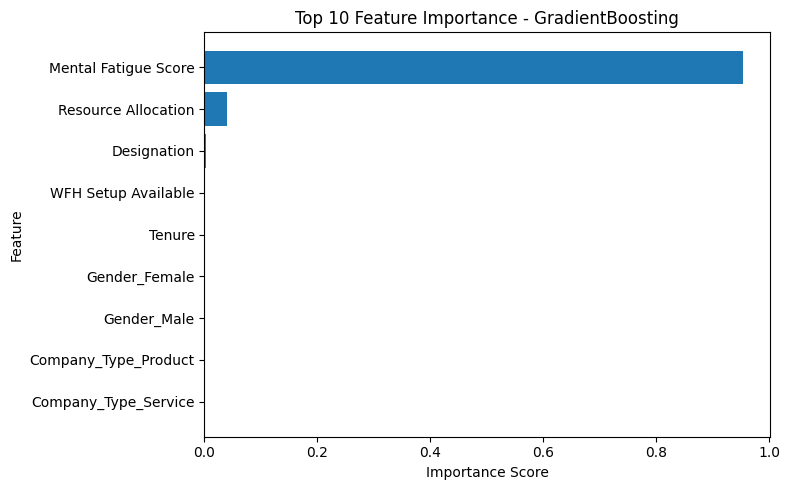


=== Feature Importance (XGBoost) ===
                Feature  Importance
3  Mental Fatigue Score    0.871374
2   Resource Allocation    0.088942
0   WFH Setup Available    0.023439
1           Designation    0.007771
4         Gender_Female    0.003837
6  Company_Type_Product    0.002517
8                Tenure    0.002120
5           Gender_Male    0.000000
7  Company_Type_Service    0.000000


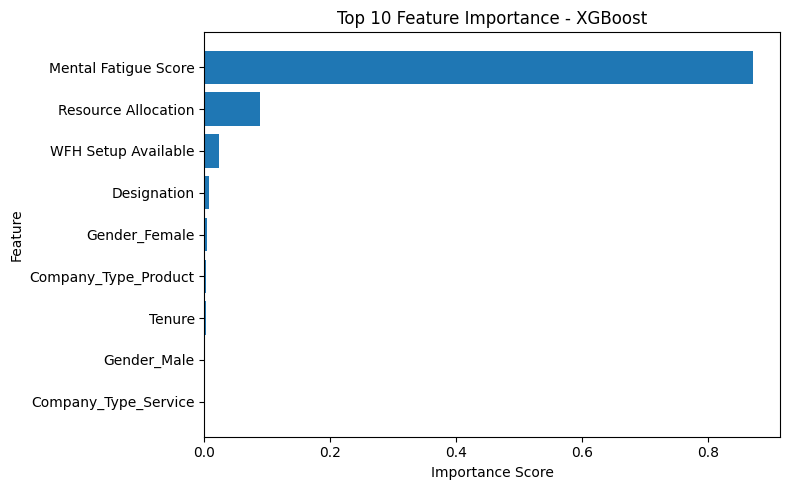

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 369
[LightGBM] [Info] Number of data points in the train set: 14872, number of used features: 9
[LightGBM] [Info] Start training from score 0.452021
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

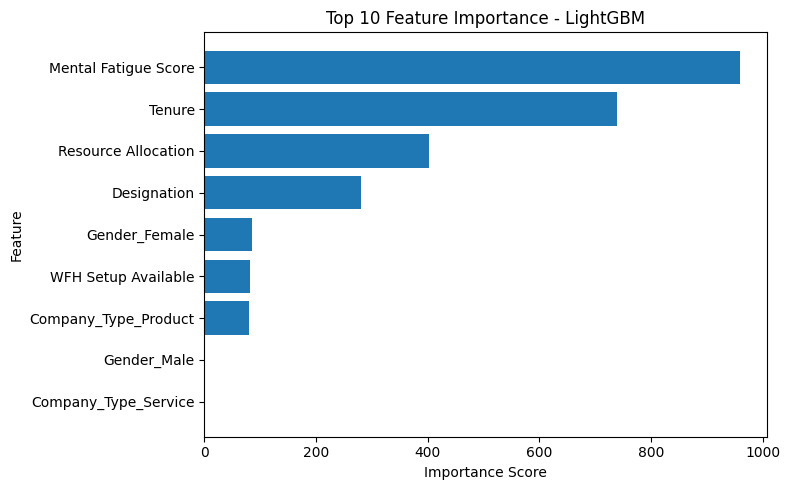

In [ ]:
# ============================================
# FEATURE IMPORTANCE UNTUK SEMUA BOOSTING MODELS
# ============================================

for name, model in boosting_models.items():
    model.fit(X_train, y_train)

    # Ambil nilai importance
    importance = model.feature_importances_

    # Buat dataframe feature importance
    feat_imp = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    # ==========================
    # 1. CETAK TABEL TOP 10
    # ==========================
    print(f"\n=== Feature Importance ({name}) ===")
    print(feat_imp.head(10))

    # ==========================
    # 2. VISUALISASI GRAFIK
    # ==========================
    plt.figure(figsize=(8, 5))
    plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
    plt.title(f"Top 10 Feature Importance - {name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()   # bikin ranking tertinggi di atas
    plt.tight_layout()
    plt.show()


=== Feature Importance (lr) ===
                Feature  Importance
3  Mental Fatigue Score    0.740900
2   Resource Allocation    0.256125
1           Designation   -0.022818
0   WFH Setup Available   -0.011111
5           Gender_Male    0.002355
4         Gender_Female   -0.002355
8                Tenure    0.001099
6  Company_Type_Product   -0.000165
7  Company_Type_Service    0.000165


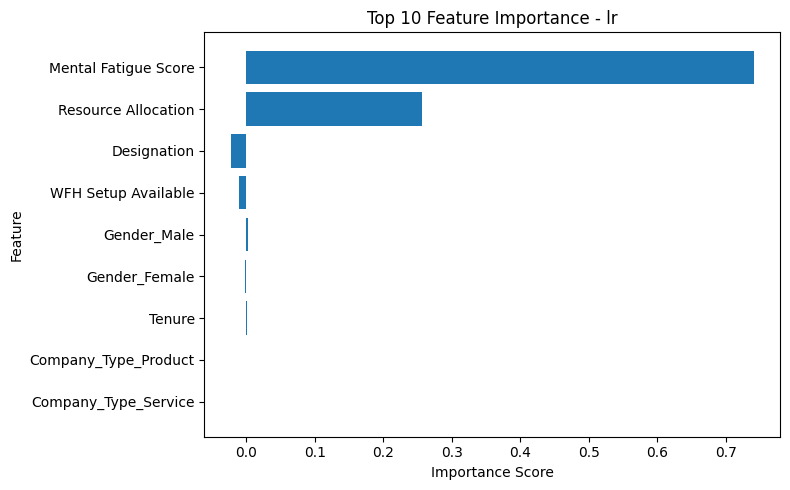


=== Feature Importance (ridge) ===
                Feature  Importance
3  Mental Fatigue Score    0.738057
2   Resource Allocation    0.256455
1           Designation   -0.021486
0   WFH Setup Available   -0.011223
5           Gender_Male    0.002387
4         Gender_Female   -0.002387
8                Tenure    0.001101
6  Company_Type_Product   -0.000164
7  Company_Type_Service    0.000164


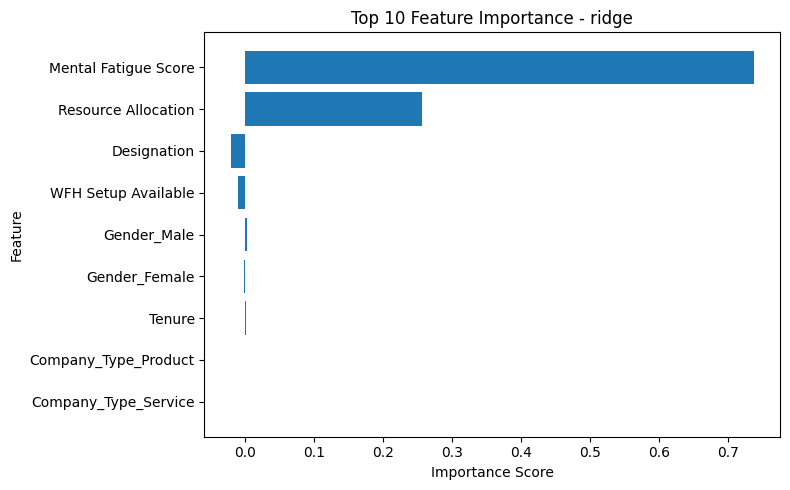

Model svr tidak punya feature importance yang bisa diambil langsung.

=== Feature Importance (rf) ===
                Feature  Importance
3  Mental Fatigue Score    0.903587
8                Tenure    0.041366
2   Resource Allocation    0.033930
1           Designation    0.006955
0   WFH Setup Available    0.004634
5           Gender_Male    0.002468
4         Gender_Female    0.002392
7  Company_Type_Service    0.002351
6  Company_Type_Product    0.002317


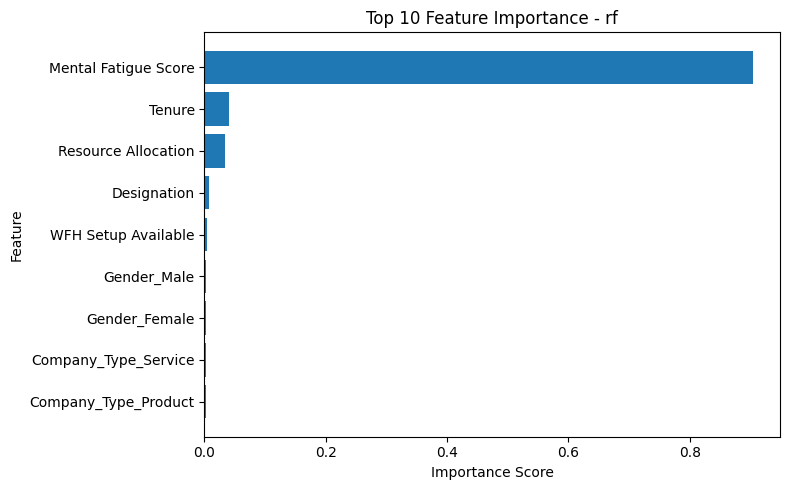


=== Feature Importance (xgb) ===
                Feature  Importance
3  Mental Fatigue Score    0.922947
2   Resource Allocation    0.044116
0   WFH Setup Available    0.018171
1           Designation    0.006994
4         Gender_Female    0.003649
6  Company_Type_Product    0.002256
8                Tenure    0.001867
5           Gender_Male    0.000000
7  Company_Type_Service    0.000000


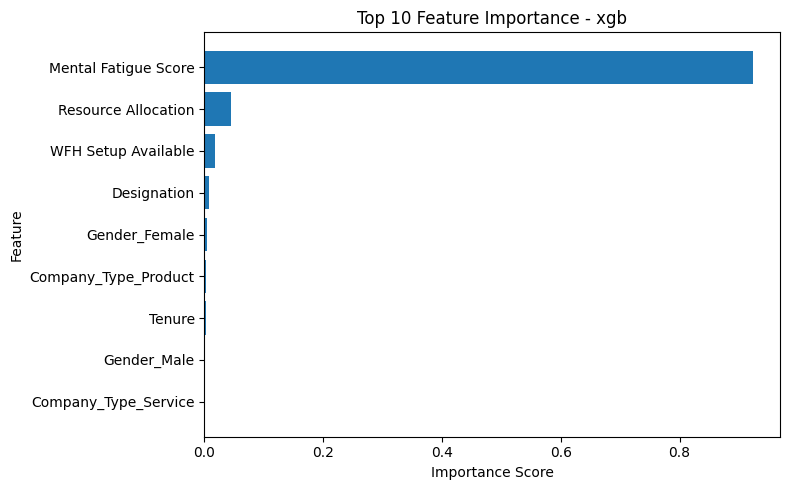

In [ ]:
# ============================================
# FEATURE IMPORTANCE UNTUK BASE LEARNERS STACKING
# ============================================

# Kita looping setiap base learner dalam stacking
for name, model in base_learners:
    model.fit(X_train, y_train)  # Latih model dengan data training

    # ===========================
    # Ambil nilai feature importance
    # ===========================
    # Untuk model linear (LinearRegression, Ridge) kita ambil koefisiennya
    # Untuk RandomForest dan XGBoost, ambil feature_importances_
    # Untuk SVR dengan kernel rbf tidak tersedia feature importance
    if name in ["lr", "ridge"]:
        importance = model.coef_
    elif name in ["rf", "xgb"]:
        importance = model.feature_importances_
    else:
        print(f"Model {name} tidak punya feature importance yang bisa diambil langsung.")
        continue

    # ===========================
    # Buat dataframe feature importance, urutkan descending
    # ===========================
    feat_imp = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    }).sort_values(by="Importance", key=abs, ascending=False)

    # ===========================
    # Cetak tabel top 10 fitur paling penting
    # ===========================
    print(f"\n=== Feature Importance ({name}) ===")
    print(feat_imp.head(10))

    # ===========================
    # Visualisasi grafik bar horizontal
    # ===========================
    plt.figure(figsize=(8, 5))
    plt.barh(feat_imp["Feature"][:10], feat_imp["Importance"][:10])
    plt.title(f"Top 10 Feature Importance - {name}")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis()  # Biar fitur dengan importance terbesar muncul di atas
    plt.tight_layout()
    plt.show()
